<a href="https://colab.research.google.com/github/faiizshah7-ai/GUI/blob/main/Final_CNN_LSTM_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gradio joblib

print("Required libraries installed successfully.")

Required libraries installed successfully.


In [2]:
import os
import random
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import gradio as gr

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    LSTM,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("Gradio version:", gr.__version__)
print("Available GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Pandas version: 2.2.2
Gradio version: 6.20.0
Available GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Create a folder for the dataset
DATA_DIR = "/content/NSL_KDD"
os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "KDDTrain+.txt")
TEST_PATH = os.path.join(DATA_DIR, "KDDTest+.txt")

# Download the training dataset
!wget -q -O "{TRAIN_PATH}" \
"https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"

# Download the testing dataset
!wget -q -O "{TEST_PATH}" \
"https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

# Check that both files were downloaded
if not os.path.exists(TRAIN_PATH) or os.path.getsize(TRAIN_PATH) == 0:
    raise FileNotFoundError("KDDTrain+.txt was not downloaded correctly.")

if not os.path.exists(TEST_PATH) or os.path.getsize(TEST_PATH) == 0:
    raise FileNotFoundError("KDDTest+.txt was not downloaded correctly.")

print("Dataset downloaded successfully.")
print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)
print("Training file size:", round(os.path.getsize(TRAIN_PATH) / 1_000_000, 2), "MB")
print("Testing file size:", round(os.path.getsize(TEST_PATH) / 1_000_000, 2), "MB")

Dataset downloaded successfully.
Training file: /content/NSL_KDD/KDDTrain+.txt
Testing file: /content/NSL_KDD/KDDTest+.txt
Training file size: 19.11 MB
Testing file size: 3.44 MB


In [4]:
COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack",
    "level"
]

print("Number of columns:", len(COLUMNS))

Number of columns: 43


In [5]:
# Load the files without treating the first row as a header
train_df = pd.read_csv(
    TRAIN_PATH,
    names=COLUMNS,
    header=None
)

test_df = pd.read_csv(
    TEST_PATH,
    names=COLUMNS,
    header=None
)

# Verify the number of columns
if train_df.shape[1] != 43:
    raise ValueError(
        f"Training dataset should contain 43 columns, but {train_df.shape[1]} were found."
    )

if test_df.shape[1] != 43:
    raise ValueError(
        f"Testing dataset should contain 43 columns, but {test_df.shape[1]} were found."
    )

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

display(train_df.head())

Training dataset shape: (125973, 43)
Testing dataset shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
print("Missing values in training dataset:", train_df.isnull().sum().sum())
print("Missing values in testing dataset:", test_df.isnull().sum().sum())

print("\nTraining attack labels:")
print(train_df["attack"].value_counts().head(10))

Missing values in training dataset: 0
Missing values in testing dataset: 0

Training attack labels:
attack
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


In [7]:
# Convert attack names into binary labels
train_df["binary_label"] = (
    train_df["attack"].astype(str).str.strip() != "normal"
).astype(np.int32)

test_df["binary_label"] = (
    test_df["attack"].astype(str).str.strip() != "normal"
).astype(np.int32)

# The first 41 columns are the network traffic features
FEATURE_COLUMNS = COLUMNS[:-2]

X_train_raw = train_df[FEATURE_COLUMNS].copy()
X_test_raw = test_df[FEATURE_COLUMNS].copy()

y_train = train_df["binary_label"].to_numpy()
y_test = test_df["binary_label"].to_numpy()

print("Number of input features:", len(FEATURE_COLUMNS))

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts().rename(index={0: "Normal", 1: "Intrusion"}))

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts().rename(index={0: "Normal", 1: "Intrusion"}))

Number of input features: 41

Training label distribution:
Normal       67343
Intrusion    58630
Name: count, dtype: int64

Testing label distribution:
Intrusion    12833
Normal        9711
Name: count, dtype: int64


In [8]:
CATEGORICAL_COLUMNS = [
    "protocol_type",
    "service",
    "flag"
]

NUMERIC_COLUMNS = [
    column
    for column in FEATURE_COLUMNS
    if column not in CATEGORICAL_COLUMNS
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_COLUMNS
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_COLUMNS
        )
    ],
    remainder="drop",
    sparse_threshold=0,
    verbose_feature_names_out=False
)

print("Fitting the preprocessing system...")

# Fit only using training data
X_train_encoded = preprocessor.fit_transform(X_train_raw)

# Apply the same fitted preprocessing to testing data
X_test_encoded = preprocessor.transform(X_test_raw)

# Reduce memory usage
X_train_encoded = X_train_encoded.astype(np.float32)
X_test_encoded = X_test_encoded.astype(np.float32)

encoded_feature_names = preprocessor.get_feature_names_out()

print("Preprocessing completed.")
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)
print("Number of encoded features:", len(encoded_feature_names))

Fitting the preprocessing system...
Preprocessing completed.
Encoded training shape: (125973, 122)
Encoded testing shape: (22544, 122)
Number of encoded features: 122


In [9]:
print("Starting RFE feature selection.")
print("This step may take several minutes. Please wait.")

rfe_estimator = DecisionTreeClassifier(
    random_state=SEED,
    max_depth=12,
    class_weight="balanced"
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=13,
    step=5,
    verbose=1
)

X_train_selected = rfe.fit_transform(
    X_train_encoded,
    y_train
)

X_test_selected = rfe.transform(
    X_test_encoded
)

selected_feature_names = encoded_feature_names[rfe.support_]

print("\nRFE completed.")
print("Selected training shape:", X_train_selected.shape)
print("Selected testing shape:", X_test_selected.shape)

print("\nSelected features:")
for number, feature in enumerate(selected_feature_names, start=1):
    print(f"{number}. {feature}")

Starting RFE feature selection.
This step may take several minutes. Please wait.
Fitting estimator with 122 features.
Fitting estimator with 117 features.
Fitting estimator with 112 features.
Fitting estimator with 107 features.
Fitting estimator with 102 features.
Fitting estimator with 97 features.
Fitting estimator with 92 features.
Fitting estimator with 87 features.
Fitting estimator with 82 features.
Fitting estimator with 77 features.
Fitting estimator with 72 features.
Fitting estimator with 67 features.
Fitting estimator with 62 features.
Fitting estimator with 57 features.
Fitting estimator with 52 features.
Fitting estimator with 47 features.
Fitting estimator with 42 features.
Fitting estimator with 37 features.
Fitting estimator with 32 features.
Fitting estimator with 27 features.
Fitting estimator with 22 features.
Fitting estimator with 17 features.

RFE completed.
Selected training shape: (125973, 13)
Selected testing shape: (22544, 13)

Selected features:
1. duration


In [10]:
# Convert the selected features into a CNN-LSTM-compatible shape
X_train_sequence = X_train_selected.reshape(
    X_train_selected.shape[0],
    X_train_selected.shape[1],
    1
)

X_test_sequence = X_test_selected.reshape(
    X_test_selected.shape[0],
    X_test_selected.shape[1],
    1
)

# Create a validation set from the training dataset
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train_sequence,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

print("CNN-LSTM training shape:", X_fit.shape)
print("CNN-LSTM validation shape:", X_validation.shape)
print("CNN-LSTM testing shape:", X_test_sequence.shape)

CNN-LSTM training shape: (100778, 13, 1)
CNN-LSTM validation shape: (25195, 13, 1)
CNN-LSTM testing shape: (22544, 13, 1)


In [11]:
model = Sequential([
    Input(shape=(X_train_sequence.shape[1], 1)),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.20),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.20),

    LSTM(units=100),
    Dropout(0.30),

    Dense(
        units=1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,429 (458.71 KB)

 Trainable params: 117,045 (457.21 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

print("Starting CNN-LSTM training...")

history = model.fit(
    X_fit,
    y_fit,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=30,
    batch_size=256,
    callbacks=[
        early_stopping,
        reduce_learning_rate
    ],
    verbose=1
)

print("Model training completed.")

Starting CNN-LSTM training...
Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9621 - auc: 0.9937 - loss: 0.0986 - precision: 0.9577 - recall: 0.9610 - val_accuracy: 0.9686 - val_auc: 0.9962 - val_loss: 0.0995 - val_precision: 0.9653 - val_recall: 0.9673 - learning_rate: 0.0010
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9727 - auc: 0.9964 - loss: 0.0719 - precision: 0.9695 - recall: 0.9719 - val_accuracy: 0.9771 - val_auc: 0.9976 - val_loss: 0.0596 - val_precision: 0.9740 - val_recall: 0.9770 - learning_rate: 0.0010
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9754 - auc: 0.9970 - loss: 0.0655 - precision: 0.9729 - recall: 0.9743 - val_accuracy: 0.9787 - val_auc: 0.9978 - val_loss: 0.0566 - val_precision: 0.9770 - val_recall: 0.9773 - learning_rate: 0.0010
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9763 - auc: 0.9973 - loss: 0.0620 - precision: 0.9735 - recall: 0.9756 - val_accuracy: 0.9779 - val_a

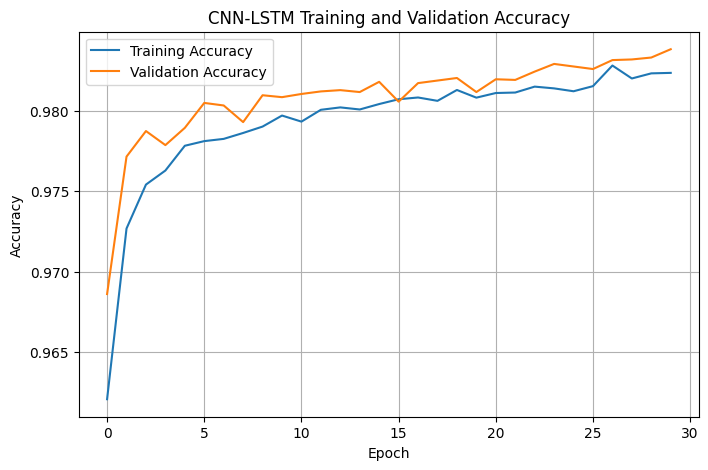

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN-LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

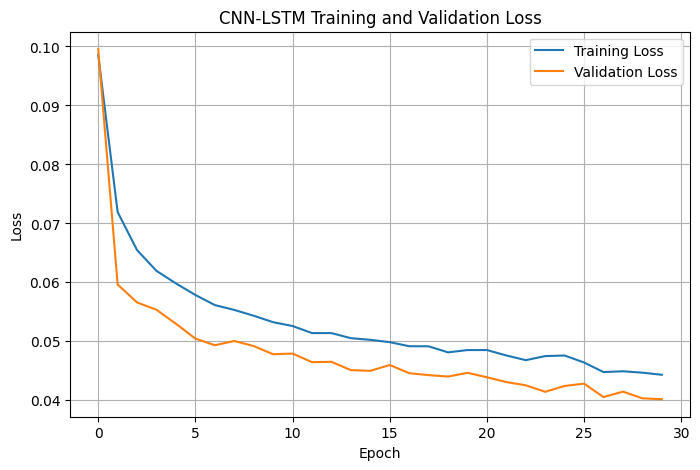

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN-LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print("Testing the trained model...")

test_probabilities = model.predict(
    X_test_sequence,
    verbose=1
).reshape(-1)

test_predictions = (
    test_probabilities >= 0.50
).astype(np.int32)

accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    test_probabilities
)

metrics_table = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Result": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

metrics_table["Result"] = metrics_table["Result"].round(4)

display(metrics_table)

Testing the trained model...
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


,Evaluation Metric,Result
0,Accuracy,0.7745
1,Precision,0.9638
2,Recall,0.6274
3,F1-Score,0.7601
4,ROC-AUC,0.9165


In [17]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Normal",
            "Intrusion"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal     0.6631    0.9689    0.7873      9711
   Intrusion     0.9638    0.6274    0.7601     12833

    accuracy                         0.7745     22544
   macro avg     0.8135    0.7982    0.7737     22544
weighted avg     0.8343    0.7745    0.7718     22544



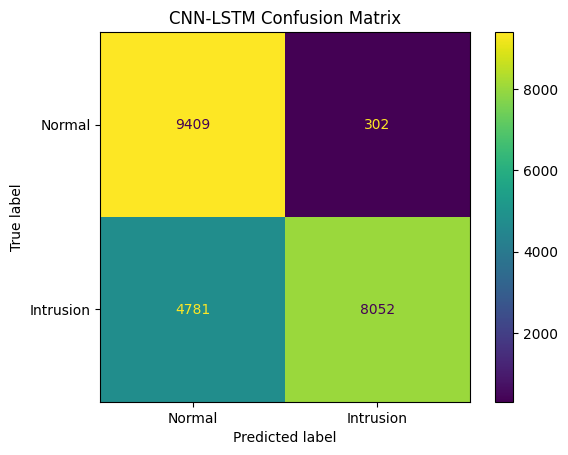

In [18]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Intrusion"
    ]
)

display_matrix.plot()
plt.title("CNN-LSTM Confusion Matrix")
plt.show()

In [19]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [20]:
SAVE_DIR = "/content/drive/MyDrive/CNN_LSTM_IDS"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

# Save the trained deep-learning model
model.save(
    os.path.join(
        SAVE_DIR,
        "cnn_lstm_ids.keras"
    )
)

# Save the preprocessing system
joblib.dump(
    preprocessor,
    os.path.join(
        SAVE_DIR,
        "preprocessor.pkl"
    )
)

# Save the RFE feature selector
joblib.dump(
    rfe,
    os.path.join(
        SAVE_DIR,
        "rfe_selector.pkl"
    )
)

# Save the selected feature names
joblib.dump(
    selected_feature_names.tolist(),
    os.path.join(
        SAVE_DIR,
        "selected_features.pkl"
    )
)

# Save evaluation results
metrics_table.to_csv(
    os.path.join(
        SAVE_DIR,
        "evaluation_metrics.csv"
    ),
    index=False
)

# Save training history
pd.DataFrame(
    history.history
).to_csv(
    os.path.join(
        SAVE_DIR,
        "training_history.csv"
    ),
    index=False
)

print("All model files were saved successfully.")
print("Saved folder:", SAVE_DIR)

All model files were saved successfully.
Saved folder: /content/drive/MyDrive/CNN_LSTM_IDS


In [21]:
DISPLAY_COLUMNS = [
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "attack"
]


def predict_test_record(row_number):
    """
    Predict one record from the NSL-KDD testing dataset.
    """

    try:
        if row_number is None:
            raise ValueError(
                "Please enter a test-record number."
            )

        row_number = int(row_number)

        if row_number < 0:
            raise ValueError(
                "The record number cannot be negative."
            )

        if row_number >= len(X_test_raw):
            raise ValueError(
                f"Enter a number between 0 and {len(X_test_raw) - 1}."
            )

        # Obtain one original testing record
        selected_raw_record = X_test_raw.iloc[
            [row_number]
        ].copy()

        # Apply the same preprocessing used during training
        selected_encoded_record = preprocessor.transform(
            selected_raw_record
        ).astype(np.float32)

        # Apply the same RFE feature selection
        selected_rfe_record = rfe.transform(
            selected_encoded_record
        )

        # Reshape for CNN-LSTM
        selected_sequence = selected_rfe_record.reshape(
            1,
            selected_rfe_record.shape[1],
            1
        )

        # Generate prediction
        intrusion_probability = float(
            model.predict(
                selected_sequence,
                verbose=0
            )[0][0]
        )

        predicted_number = int(
            intrusion_probability >= 0.50
        )

        actual_number = int(
            y_test[row_number]
        )

        predicted_label = (
            "Intrusion"
            if predicted_number == 1
            else "Normal"
        )

        actual_label = (
            "Intrusion"
            if actual_number == 1
            else "Normal"
        )

        comparison = (
            "Correct prediction"
            if predicted_number == actual_number
            else "Incorrect prediction"
        )

        record_summary = test_df.loc[
            [row_number],
            DISPLAY_COLUMNS
        ].copy()

        return (
            predicted_label,
            f"{intrusion_probability * 100:.2f}%",
            actual_label,
            comparison,
            record_summary
        )

    except Exception as error:
        return (
            "Error",
            "Not available",
            "Not available",
            str(error),
            pd.DataFrame()
        )

In [22]:
with gr.Blocks(
    title="CNN-LSTM Intrusion Detection System"
) as demo:

    gr.Markdown(
        """
        # CNN-LSTM Intrusion Detection System

        Enter a row number from the NSL-KDD testing dataset.

        The system will classify the selected network record as:

        - **Normal**
        - **Intrusion**

        Valid record range: **0 to 22543**
        """
    )

    row_number_input = gr.Number(
        label="Testing Record Number",
        value=0,
        precision=0
    )

    with gr.Row():
        predict_button = gr.Button(
            "Analyse Network Record",
            variant="primary"
        )

        clear_button = gr.ClearButton(
            value="Clear"
        )

    predicted_output = gr.Textbox(
        label="Predicted Classification"
    )

    probability_output = gr.Textbox(
        label="Intrusion Probability"
    )

    actual_output = gr.Textbox(
        label="Actual Classification"
    )

    comparison_output = gr.Textbox(
        label="Prediction Result"
    )

    record_output = gr.Dataframe(
        label="Selected Network Record",
        interactive=False
    )

    predict_button.click(
        fn=predict_test_record,
        inputs=row_number_input,
        outputs=[
            predicted_output,
            probability_output,
            actual_output,
            comparison_output,
            record_output
        ]
    )

    clear_button.add([
        row_number_input,
        predicted_output,
        probability_output,
        actual_output,
        comparison_output,
        record_output
    ])

    gr.Examples(
        examples=[
            [0],
            [10],
            [100],
            [1000],
            [5000]
        ],
        inputs=row_number_input
    )

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cacfe0d5f602cd3251.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cacfe0d5f602cd3251.gradio.live
